In [1]:

CONF_THRESHOLD  = 0.25   
IOU_THRESHOLD   = 0.45   
IOU_MATCH       = 0.5    
N_SAMPLE        = 6     

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Cihaz: {DEVICE}")

Cihaz: cpu


In [15]:
import os, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report,precision_score, recall_score, f1_score


In [19]:
MODEL_PATH = r"C:\Users\nesli\OneDrive\Masaüstü\fusebox_web\model-test\weights.pt"
IMAGES_DIR = r"C:\Users\nesli\OneDrive\Masaüstü\fusebox_web\fuseBOXV12.coco\train"         
COCO_JSON  = r"C:\Users\nesli\OneDrive\Masaüstü\fusebox_web\fuseBOXV12.coco\_annotations.coco.json"


In [20]:

with open(COCO_JSON) as f:
    coco = json.load(f)

cat_map = {c["id"]: c["name"] for c in coco["categories"] if c["supercategory"] != "none"}
CLASS_NAMES = sorted(cat_map.values())
print(f"Sınıflar ({len(CLASS_NAMES)}): {CLASS_NAMES}")

# (id → {file_name, width, height})
img_map = {i["id"]: i for i in coco["images"]}
print(f"Toplam görüntü : {len(img_map)}")
print(f"Toplam annotation: {len(coco['annotations'])}")

#file_name: [{cat, x1,y1,x2,y2}, ...]}
gt_by_file = {}
for ann in coco["annotations"]:
    img_info = img_map[ann["image_id"]]
    fname    = img_info["file_name"]
    W, H     = img_info["width"], img_info["height"]
    x, y, w, h = [float(v) for v in ann["bbox"]]          # COCO: x_min, y_min, w, h  (pixel)
    cat_name = cat_map.get(ann["category_id"])
    if cat_name is None:
        continue                       # parent kategoriyi atla
    gt_by_file.setdefault(fname, []).append({
        "cat": cat_name,
        "x1": x, "y1": y,
        "x2": x + w, "y2": y + h
    })

print(f"Annotation içeren görüntü: {len(gt_by_file)}")

Sınıflar (8): ['10_amp', '15_amp', '20_amp', '25_amp', '2_amp', '30_amp', '5_amp', '7.5_amp']
Toplam görüntü : 126
Toplam annotation: 9572
Annotation içeren görüntü: 126


In [21]:
model = YOLO(MODEL_PATH)

yolo_names = model.names   # {0: '10_amp', 1: '15_amp', ...}
print("YOLO sınıfları:", yolo_names)

img_exts = ('.jpg')
all_images = sorted([
    f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(img_exts)
])
print(f"Klasörde {len(all_images)} görüntü bulundu")

# Inference
results_map = {}   # file_name → ultralytics result
for fname in tqdm(all_images, desc="Inference"):
    path = os.path.join(IMAGES_DIR, fname)
    res  = model.predict(path, conf=CONF_THRESHOLD,
                         iou=IOU_THRESHOLD, verbose=False)[0]
    results_map[fname] = res

print("+")

YOLO sınıfları: {0: '10_amp', 1: '15_amp', 2: '20_amp', 3: '25_amp', 4: '2_amp', 5: '30_amp', 6: '5_amp', 7: '7.5_amp'}
Klasörde 126 görüntü bulundu


Inference: 100%|██████████| 126/126 [00:11<00:00, 11.18it/s]

+


In [22]:
def iou(a, b):
    """İki bbox (x1,y1,x2,y2) arasındaki IoU"""
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a_area = (a[2]-a[0]) * (a[3]-a[1])
    b_area = (b[2]-b[0]) * (b[3]-b[1])
    union  = a_area + b_area - inter
    return inter / union if union > 0 else 0

y_true, y_pred = [], []

for fname, res in results_map.items():
    gts   = gt_by_file.get(fname, [])
    boxes = res.boxes

    pred_list = []
    if len(boxes):
        for i in range(len(boxes)):
            x1,y1,x2,y2 = boxes.xyxy[i].cpu().numpy()
            cls_id = int(boxes.cls[i].cpu())
            pred_list.append({"cat": yolo_names[cls_id],
                               "x1":x1,"y1":y1,"x2":x2,"y2":y2,
                               "matched": False})

    matched_gt = set()
    for gt in gts:
        best_iou, best_p = 0, None
        for p in pred_list:
            if p["matched"]:
                continue
            v = iou((gt["x1"],gt["y1"],gt["x2"],gt["y2"]),
                    (p["x1"], p["y1"], p["x2"], p["y2"]))
            if v > best_iou:
                best_iou, best_p = v, p

        if best_iou >= IOU_MATCH and best_p is not None:
            y_true.append(gt["cat"])
            y_pred.append(best_p["cat"])
            best_p["matched"] = True
        else:
            # GT var ama tespit yok → False Negative
            y_true.append(gt["cat"])
            y_pred.append("__missed__")

    # Eşleşmeyen tahminler → False Positive
    for p in pred_list:
        if not p["matched"]:
            y_true.append("__background__")
            y_pred.append(p["cat"])

print(f"Toplam GT kutusu   : {sum(len(v) for v in gt_by_file.values())}")
print(f"Toplam tahmin kutusu: {sum(len(r.boxes) for r in results_map.values())}")
print(f"Eşleştirilen çift  : {sum(1 for t,p in zip(y_true,y_pred) if t==p)}")

Toplam GT kutusu   : 9572
Toplam tahmin kutusu: 9590
Eşleştirilen çift  : 9417


Metrikler

In [23]:
# Sadece gerçek sınıflara bak (missed / background hariç)
mask   = [(t in CLASS_NAMES and p in CLASS_NAMES) for t,p in zip(y_true, y_pred)]
yt_cls = [t for t,m in zip(y_true, mask) if m]
yp_cls = [p for p,m in zip(y_pred, mask) if m]

labels_present = sorted(set(yt_cls) | set(yp_cls))

acc  = sum(t==p for t,p in zip(yt_cls,yp_cls)) / len(yt_cls) if yt_cls else 0
prec = precision_score(yt_cls, yp_cls, labels=labels_present, average='weighted', zero_division=0)
rec  = recall_score(yt_cls, yp_cls, labels=labels_present, average='weighted', zero_division=0)
f1   = f1_score(yt_cls, yp_cls, labels=labels_present, average='weighted', zero_division=0)

fn = sum(1 for p in y_pred if p == '__missed__')
fp = sum(1 for t in y_true if t == '__background__')

print("=" * 48)
print("         DETECTION METRİKLERİ")
print("=" * 48)
print(f"  Sınıf doğruluğu (eşleşenlerde) : {acc*100:.2f}%")
print(f"  Weighted Precision              : {prec*100:.2f}%")
print(f"  Weighted Recall                 : {rec*100:.2f}%")
print(f"  Weighted F1                     : {f1*100:.2f}%")
print(f"  False Negative (kaçırılan)      : {fn}")
print(f"  False Positive (yanlış alarm)   : {fp}")
print("=" * 48)
print()
print(classification_report(yt_cls, yp_cls, labels=labels_present, zero_division=0))

         DETECTION METRİKLERİ
  Sınıf doğruluğu (eşleşenlerde) : 98.52%
  Weighted Precision              : 98.68%
  Weighted Recall                 : 98.52%
  Weighted F1                     : 98.53%
  False Negative (kaçırılan)      : 14
  False Positive (yanlış alarm)   : 32

              precision    recall  f1-score   support

      10_amp       1.00      1.00      1.00      1560
      15_amp       1.00      1.00      1.00      1170
      20_amp       1.00      1.00      1.00      1091
      25_amp       0.89      1.00      0.94      1013
       2_amp       1.00      1.00      1.00      1169
      30_amp       1.00      1.00      1.00       937
       5_amp       1.00      0.91      0.95      1604
     7.5_amp       0.99      1.00      0.99      1014

    accuracy                           0.99      9558
   macro avg       0.98      0.99      0.99      9558
weighted avg       0.99      0.99      0.99      9558



Confusion Matrix

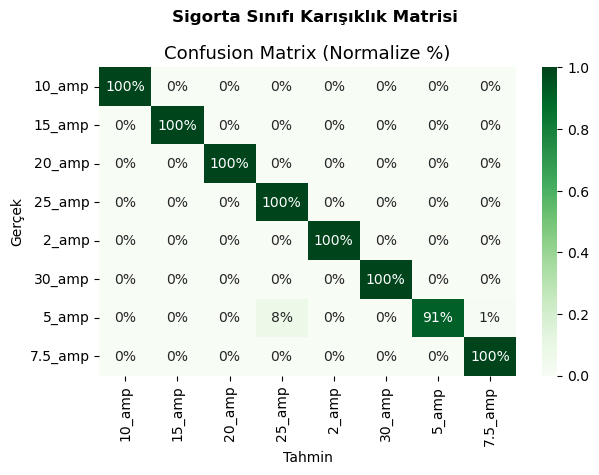

In [27]:
from streamlit import title

cm = confusion_matrix(yt_cls, yp_cls, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Greens',
            xticklabels=labels_present, yticklabels=labels_present)
plt.title('Confusion Matrix (Normalize %)', fontsize=13)
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')

plt.suptitle('Sigorta Sınıfı Karışıklık Matrisi', fontweight='bold')
plt.tight_layout()
plt.show()


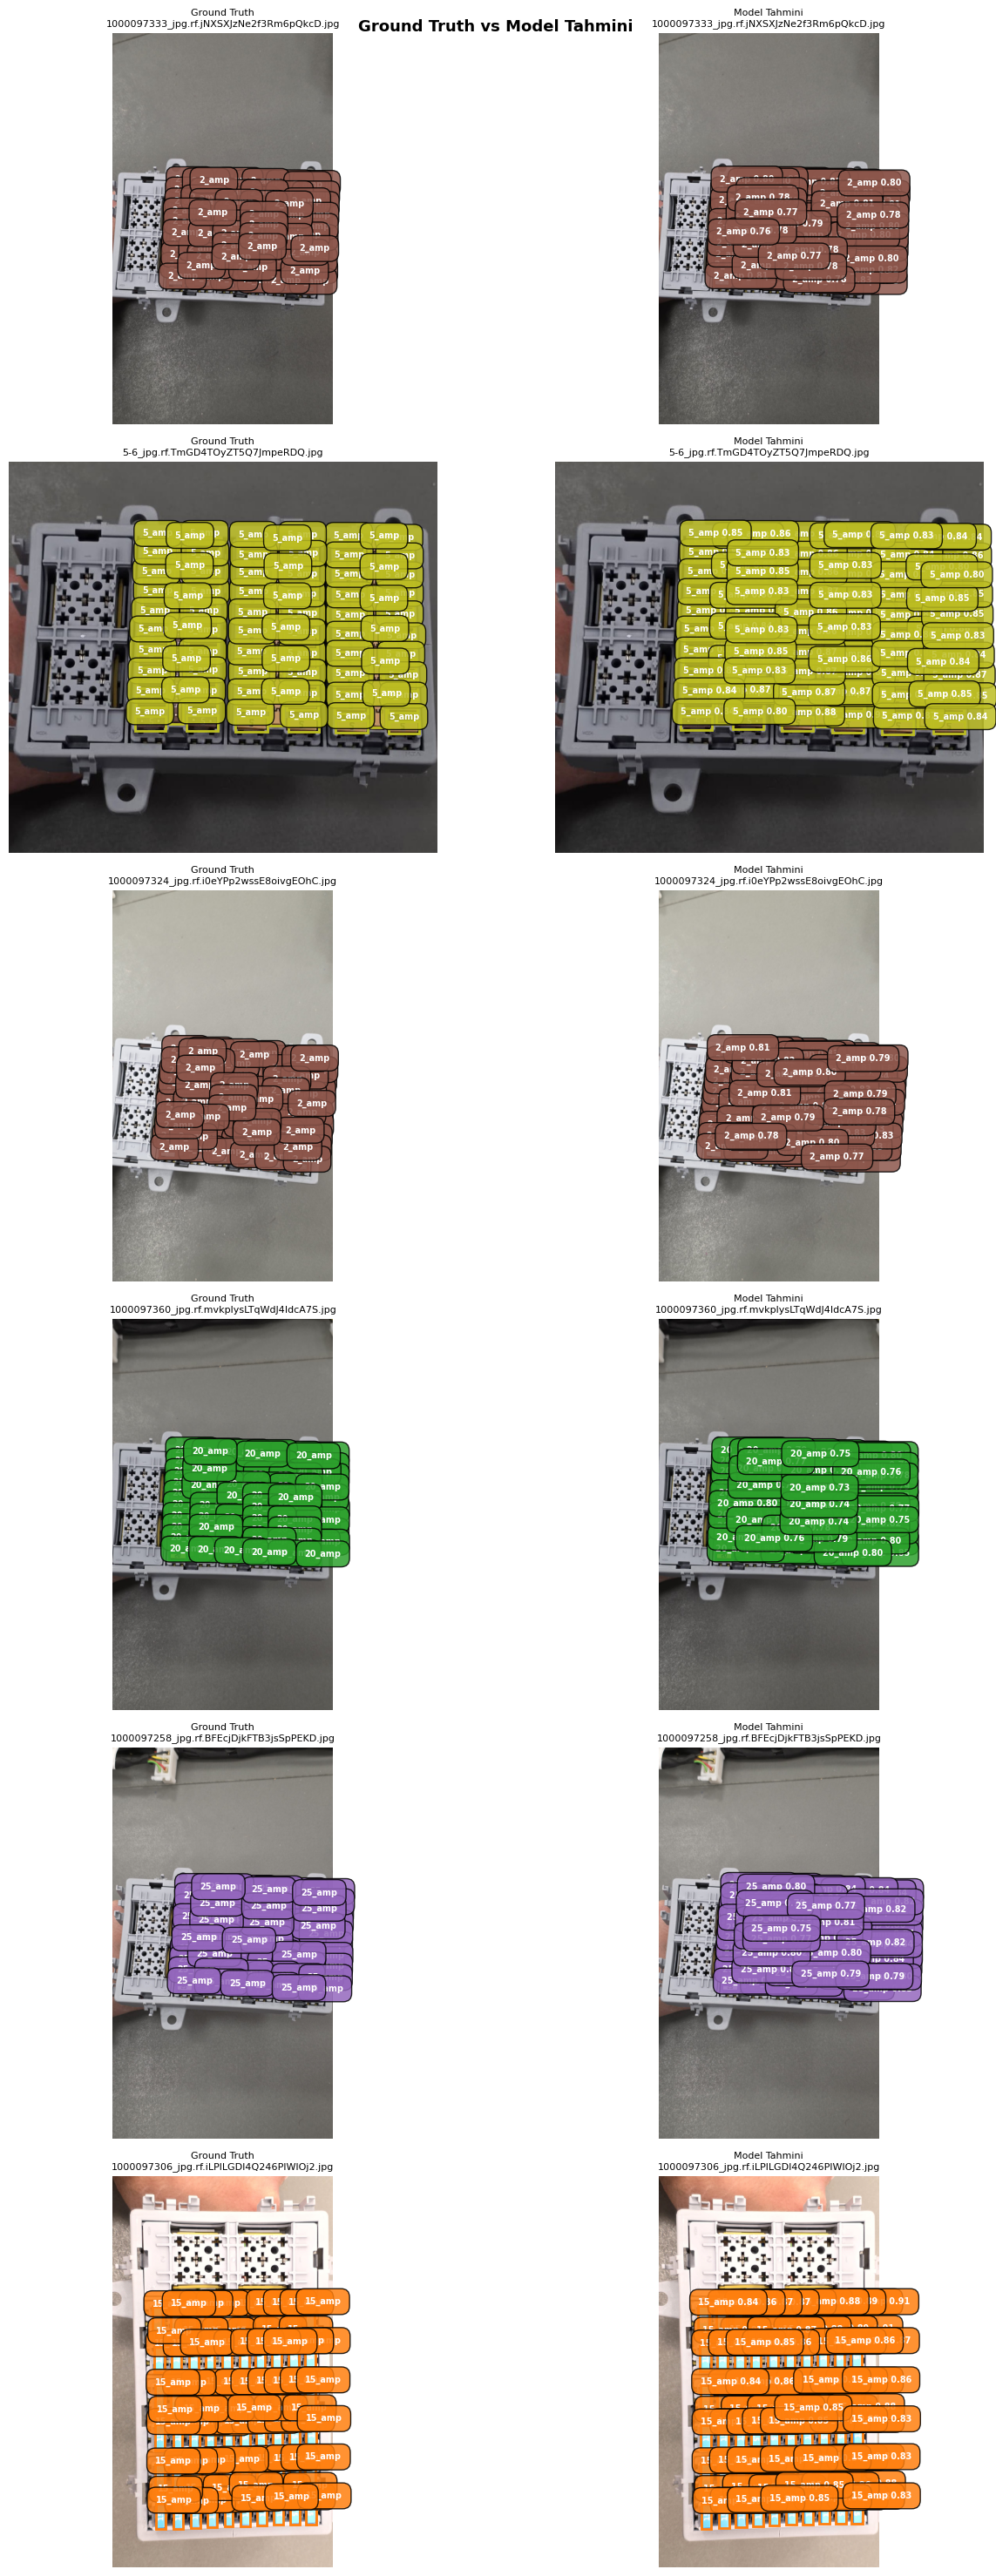

In [28]:
COLORS = plt.cm.get_cmap('tab10', len(CLASS_NAMES))
cls2color = {c: COLORS(i) for i, c in enumerate(CLASS_NAMES)}

sample_files = random.sample(list(results_map.keys()), min(N_SAMPLE, len(results_map)))

fig, axes = plt.subplots(N_SAMPLE, 2, figsize=(14, N_SAMPLE * 5))
if N_SAMPLE == 1:
    axes = [axes]

for row, fname in enumerate(sample_files):
    img_path = os.path.join(IMAGES_DIR, fname)
    img = Image.open(img_path).convert('RGB')
    W, H = img.size

    for col, (title, annotations) in enumerate([
        ("Ground Truth",  gt_by_file.get(fname, [])),
        ("Model Tahmini", [{
            "cat":  yolo_names[int(b.cls.cpu())],
            "x1": float(b.xyxy[0][0]), "y1": float(b.xyxy[0][1]),
            "x2": float(b.xyxy[0][2]), "y2": float(b.xyxy[0][3]),
            "conf": float(b.conf.cpu())
        } for b in results_map[fname].boxes])
    ]):
        ax = axes[row][col]
        ax.imshow(img)
        for ann in annotations:
            color = cls2color.get(ann['cat'], (1,0,0,1))
            rect  = patches.Rectangle(
                (ann['x1'], ann['y1']),
                ann['x2']-ann['x1'], ann['y2']-ann['y1'],
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            label = ann['cat']
            if 'conf' in ann:
                label += f" {ann['conf']:.2f}"
            ax.text(ann['x1'], ann['y1']-4, label,
                    color='white', fontsize=7, fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.85, pad=1, boxstyle='round'))
        ax.set_title(f"{title}\n{fname}", fontsize=8)
        ax.axis('off')

plt.suptitle('Ground Truth vs Model Tahmini', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


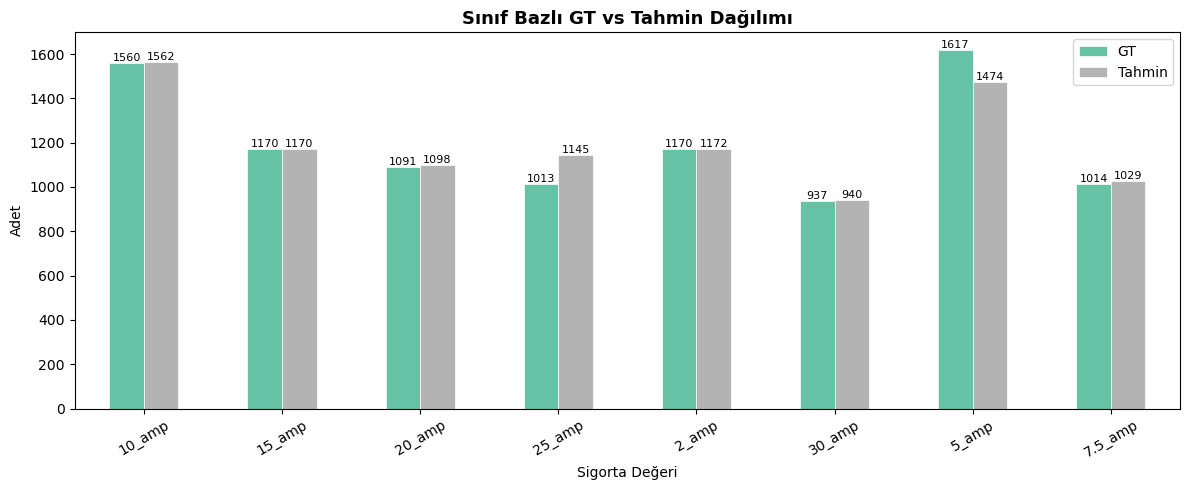

In [29]:
# GT dağılımı
gt_counts   = pd.Series([a["cat"] for gts in gt_by_file.values() for a in gts]).value_counts()
# Tahmin dağılımı
pred_counts = pd.Series([yolo_names[int(b.cls)] 
                          for r in results_map.values() 
                          for b in r.boxes]).value_counts()

df_dist = pd.DataFrame({'GT': gt_counts, 'Tahmin': pred_counts}).fillna(0).astype(int)
df_dist = df_dist.sort_index()

ax = df_dist.plot(kind='bar', figsize=(12,5), colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('Sınıf Bazlı GT vs Tahmin Dağılımı', fontsize=13, fontweight='bold')
ax.set_xlabel('Sigorta Değeri')
ax.set_ylabel('Adet')
ax.tick_params(axis='x', rotation=30)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.tight_layout()
plt.show()


In [30]:
print("=" * 50)
print("            ÖZET RAPOR")
print("=" * 50)
print(f"  Model          : {MODEL_PATH}")
print(f"  Test görüntüsü : {len(all_images)}")
print(f"  Sınıf sayısı   : {len(CLASS_NAMES)}")
print(f"  Toplam GT kutu : {sum(len(v) for v in gt_by_file.values())}")
print(f"  Toplam tahmin  : {sum(len(r.boxes) for r in results_map.values())}")
print(f"  Sınıf Acc.     : {acc*100:.2f}%")
print(f"  F1 (weighted)  : {f1*100:.2f}%")
print(f"  Kaçırılan (FN) : {fn}")
print(f"  Yanlış alarm(FP): {fp}")
print("=" * 50)


            ÖZET RAPOR
  Model          : C:\Users\nesli\OneDrive\Masaüstü\fusebox_web\model-test\weights.pt
  Test görüntüsü : 126
  Sınıf sayısı   : 8
  Toplam GT kutu : 9572
  Toplam tahmin  : 9590
  Sınıf Acc.     : 98.52%
  F1 (weighted)  : 98.53%
  Kaçırılan (FN) : 14
  Yanlış alarm(FP): 32


Görüntü      : C:\Users\nesli\OneDrive\Masaüstü\fusebox_web\model-test\deneme3.jpeg
Tespit sayısı: 80
----------------------------------------
  20_amp       güven: 0.93   bbox: [587,1118,649,1263]
  20_amp       güven: 0.90   bbox: [585,880,648,1022]
  20_amp       güven: 0.90   bbox: [890,1033,1042,1099]
  20_amp       güven: 0.90   bbox: [591,649,651,791]
  20_amp       güven: 0.90   bbox: [580,1353,644,1504]
  20_amp       güven: 0.90   bbox: [578,1600,645,1755]
  20_amp       güven: 0.90   bbox: [728,1032,879,1095]
  10_amp       güven: 0.89   bbox: [105,571,252,633]
  15_amp       güven: 0.89   bbox: [288,654,353,794]
  10_amp       güven: 0.89   bbox: [199,427,260,564]
  10_amp       güven: 0.87   bbox: [188,654,251,793]
  20_amp       güven: 0.85   bbox: [590,422,652,560]
  5_amp        güven: 0.83   bbox: [893,1519,1044,1586]
  15_amp       güven: 0.83   bbox: [271,1349,338,1501]
  10_amp       güven: 0.82   bbox: [168,1345,233,1498]
  5_amp        güven: 0.82   bbox: [416,564

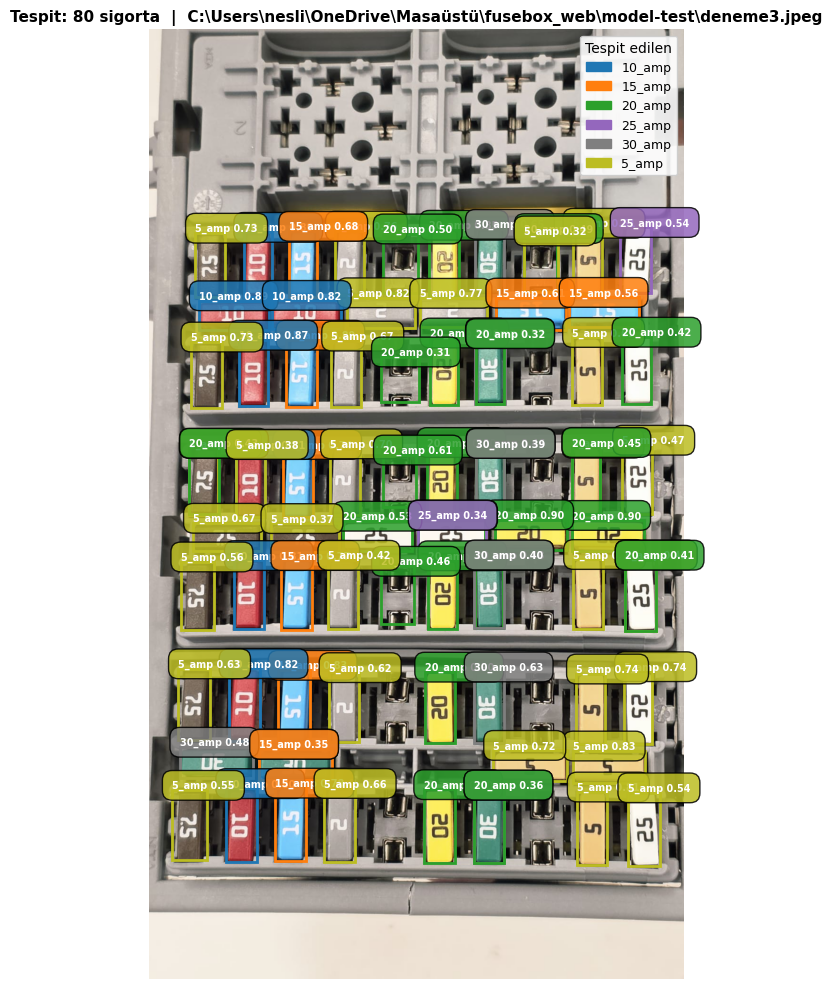

In [37]:
TEST_IMAGE = r"C:\Users\nesli\OneDrive\Masaüstü\fusebox_web\model-test\deneme3.jpeg"

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

res = model.predict(TEST_IMAGE, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]
img = Image.open(TEST_IMAGE).convert('RGB')

boxes = res.boxes
print(f"Görüntü      : {TEST_IMAGE}")
print(f"Tespit sayısı: {len(boxes)}")
print("-" * 40)

det_summary = {}
for b in boxes:
    cls_name = yolo_names[int(b.cls.cpu())]
    conf     = float(b.conf.cpu())
    det_summary[cls_name] = det_summary.get(cls_name, 0) + 1
    x1,y1,x2,y2 = b.xyxy[0].cpu().numpy()
    print(f"  {cls_name:<12} güven: {conf:.2f}   bbox: [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")

print("-" * 40)
print("Sınıf özeti:")
for k,v in sorted(det_summary.items()):
    print(f"  {k}: {v} adet")

COLORS = plt.cm.get_cmap('tab10', len(yolo_names))
cls2color = {name: COLORS(i) for i, name in yolo_names.items()}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(img)

for b in boxes:
    cls_name = yolo_names[int(b.cls.cpu())]
    conf     = float(b.conf.cpu())
    x1,y1,x2,y2 = b.xyxy[0].cpu().numpy()
    color = cls2color[cls_name]

    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1-4, f"{cls_name} {conf:.2f}",
            color='white', fontsize=7, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.85, pad=1, boxstyle='round'))

handles = [patches.Patch(color=cls2color[n], label=n) for n in sorted(det_summary)]
ax.legend(handles=handles, loc='upper right', fontsize=9,
          framealpha=0.9, title='Tespit edilen')
ax.set_title(f"Tespit: {len(boxes)} sigorta  |  {TEST_IMAGE.split('/')[-1]}",
             fontsize=11, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()